In [2]:
# pip install pillow pandas numpy matplotlib seaborn tqdm opencv-python

# Базовая статистика

In [3]:
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
from tqdm import tqdm

IMAGE_DIR = Path("test_images")

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows = []

for path in tqdm(list(IMAGE_DIR.rglob("*"))):
    if path.suffix.lower() not in extensions:
        continue

    try:
        with Image.open(path) as img:
            width, height = img.size

            rows.append({
                "path": str(path),
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
                "pixels": width * height,
                "mode": img.mode,
            })

    except Exception as e:
        print("Error:", path, e)

df = pd.DataFrame(rows)

100%|██████████| 20000/20000 [04:06<00:00, 81.21it/s] 


Количество изображений: 20000
              width        height  aspect_ratio         pixels
count  20000.000000  20000.000000  20000.000000   20000.000000
mean     357.603600     64.398150      6.220858   37143.710050
std      318.933591     59.337019      4.267151   68003.337018
min       25.000000     10.000000      0.720930     275.000000
25%      129.000000     27.000000      3.503241    3900.000000
50%      238.000000     42.000000      4.894899    9932.000000
75%      479.250000     76.000000      7.518636   34726.500000
max     1599.000000    492.000000     49.666667  702368.000000

Режимы:
mode
RGB    20000
Name: count, dtype: int64


In [4]:
print("Количество изображений:", len(df))
print(df.describe().T)
print("\nРежимы:")
print(df["mode"].value_counts())

Количество изображений: 20000
                count          mean           std        min          25%  \
width         20000.0    357.603600    318.933591   25.00000   129.000000   
height        20000.0     64.398150     59.337019   10.00000    27.000000   
aspect_ratio  20000.0      6.220858      4.267151    0.72093     3.503241   
pixels        20000.0  37143.710050  68003.337018  275.00000  3900.000000   

                      50%           75%            max  
width          238.000000    479.250000    1599.000000  
height          42.000000     76.000000     492.000000  
aspect_ratio     4.894899      7.518636      49.666667  
pixels        9932.000000  34726.500000  702368.000000  

Режимы:
mode
RGB    20000
Name: count, dtype: int64


# Размеры картинок

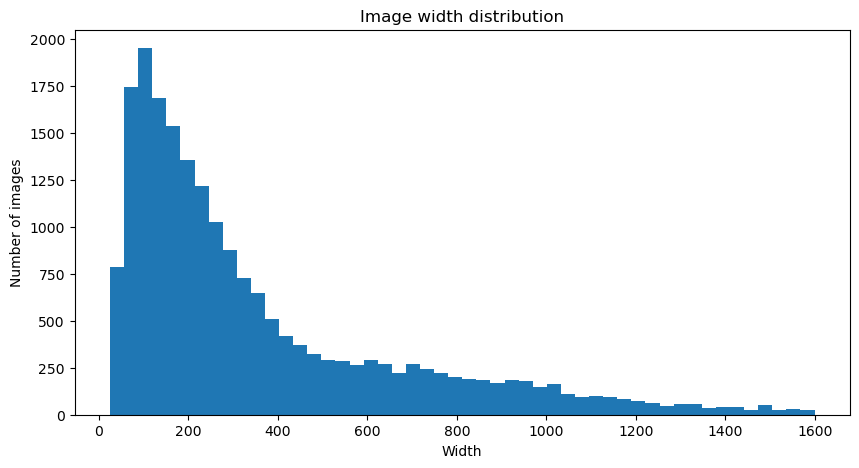

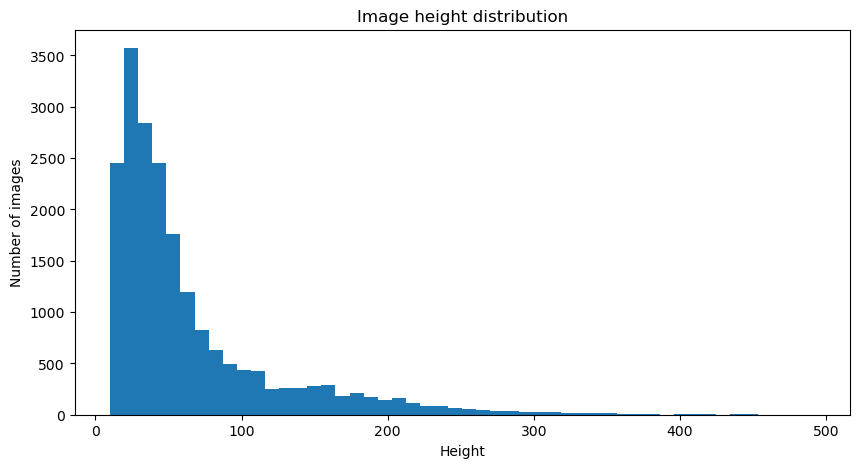

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["width"], bins=50)
plt.xlabel("Width")
plt.ylabel("Number of images")
plt.title("Image width distribution")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["height"], bins=50)
plt.xlabel("Height")
plt.ylabel("Number of images")
plt.title("Image height distribution")
plt.show()

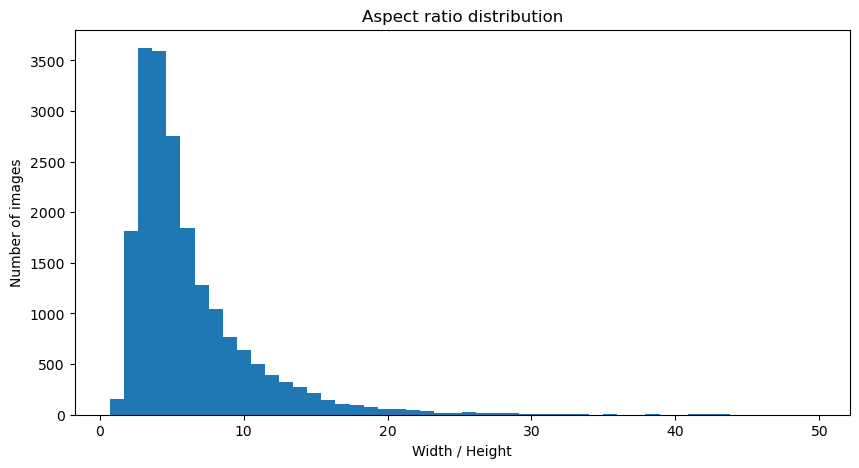

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df["aspect_ratio"], bins=50)
plt.xlabel("Width / Height")
plt.ylabel("Number of images")
plt.title("Aspect ratio distribution")
plt.show()

# Качество изображений

In [7]:
import cv2

def get_image_stats(path):
    img = cv2.imread(str(path))

    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return {
        "brightness": gray.mean(),
        "contrast": gray.std(),
        "blur": cv2.Laplacian(gray, cv2.CV_64F).var()
    }


stats = []

for path in tqdm(df["path"]):
    result = get_image_stats(path)

    if result:
        stats.append(result)

stats_df = pd.DataFrame(stats)

df = pd.concat([df.reset_index(drop=True), stats_df], axis=1)

100%|██████████| 20000/20000 [00:48<00:00, 412.38it/s]


In [8]:
print(df[["brightness", "contrast", "blur"]].describe())

         brightness      contrast          blur
count  20000.000000  20000.000000  20000.000000
mean     140.725331     49.528627   2647.492325
std       52.285683     20.574959   4682.378181
min        5.700670      1.438492      1.840794
25%       99.520816     34.025670    219.708661
50%      142.164336     47.942152    798.050974
75%      184.352842     63.885075   2975.238614
max      252.264654    119.765044  77903.031471


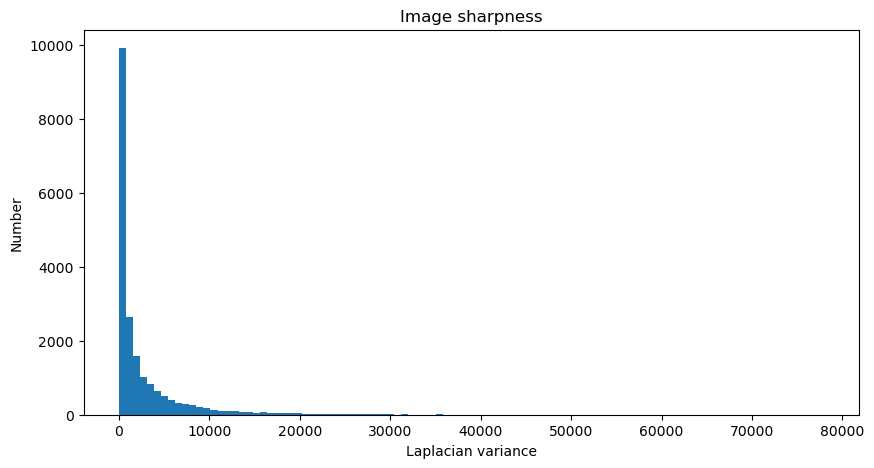

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(df["blur"], bins=100)
plt.xlabel("Laplacian variance")
plt.ylabel("Number")
plt.title("Image sharpness")
plt.show()

# Экстремальные фото

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_image(df, fg_size):
    fig, axes = plt.subplots(2, 3, figsize=fg_size)
    for ax, (_, row) in zip(axes.flat, df.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

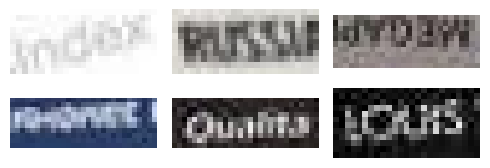

In [31]:
small_df = df.nsmallest(6, "pixels")[[
    "path", "width", "height", "aspect_ratio"
]]

show_image(small_df, (5, 2))

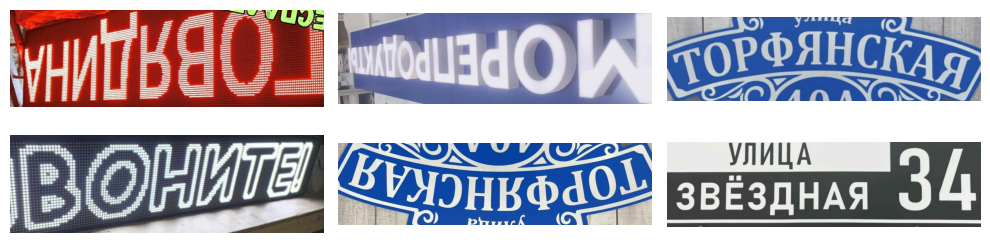

In [30]:
large_df = df.nlargest(6, "pixels")[[
    "path", "width", "height", "aspect_ratio"
]]

show_image(large_df, (10, 3))

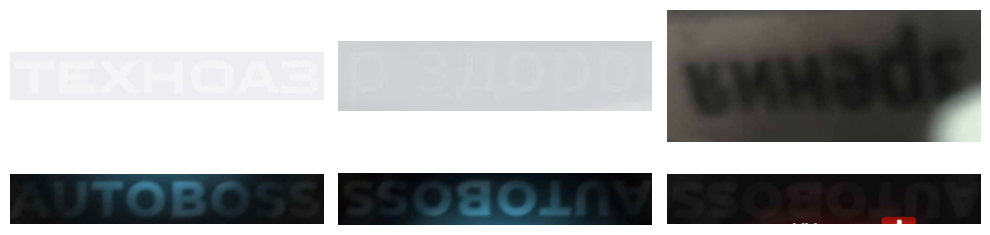

In [32]:
bl_small_df = df.nsmallest(6, "blur")[[
    "path", "blur"
]]

show_image(bl_small_df, (10, 3))

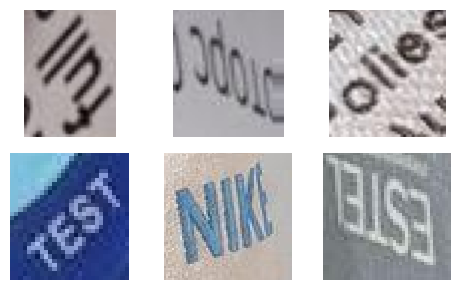

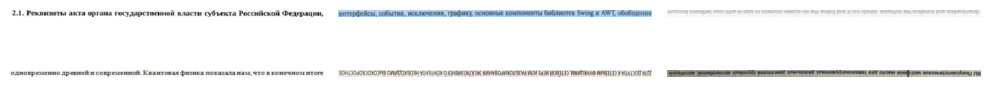

In [34]:
head_df = df.sort_values("aspect_ratio").head(6)
tail_df = df.sort_values("aspect_ratio").tail(6)

show_image(head_df, (5, 3))
show_image(tail_df, (10, 2))